In [30]:
# Neural IR Exercise dengan BERT Cross-Encoder
# Dosen     :  Zico Pratama Putra
# Kelompok  :  Rizqia - Tungkot - Intan
# Tanggal   :  18 Juni 2026

# 1. Install requirement
!pip install -q transformers>=4.30.0 datasets>=2.10.0 pandas numpy scikit-learn tqdm matplotlib seaborn jupyter ipywidgets requests

In [31]:
from google.colab import drive
import os
import sys

# Hubungkan ke Google Drive
drive.mount('/content/drive')

# Membaca folder 'src' di Drive
PROJECT_PATH = '/content/drive/My Drive/Tugas Lab Neural IR'
sys.path.append(PROJECT_PATH)

# Berpindah ke folder utama proyek
os.chdir(PROJECT_PATH)
print(f"Lingkungan dikonfigurasi!")
print(f"Direktori aktif saat ini: {os.getcwd()}")
print(f"Isi folder proyek kamu: {os.listdir('.')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Lingkungan dikonfigurasi!
 Direktori aktif saat ini: /content/drive/My Drive/Tugas Lab Neural IR
 Isi folder proyek kamu: ['data', 'src', '=4.30.0', '=2.10.0']


In [32]:
## Part 1: FiRA Judgement Aggregation
from src.judgement_aggregation import load_raw_judgements, aggregate_judgements, save_qrels

# 1. Memuat data asli judgements dari Drive
df = load_raw_judgements("data/fira_raw_judgements.tsv")

# 2. Agregasi menggunakan metode advanced terbobot yang sudah kita perbaiki
agg_df = aggregate_judgements(df, method='advanced')

# 3. Menyimpan hasil akhir ke format qrels TREC
save_qrels(agg_df, "data/fira_aggregated.qrels")

Loaded 237 raw judgements
Columns: ['query_id', 'doc_id', 'judgement', 'confidence', 'annotator_id', 'duration_ms']
   query_id doc_id  judgement  confidence annotator_id  duration_ms
0         1   d1_1          3        0.85       User_5        30289
1         1   d1_1          3        0.94       User_0        83482
2         1   d1_1          3        0.92       User_4        16165
3         1   d1_2          2        0.81       User_0        38062
4         1   d1_2          1        0.92       User_5        12851
Aggregated into 79 unique query-doc pairs
Qrels saved to data/fira_aggregated.qrels


In [33]:
## Part 2: BERT Cross-Encoder Re-Ranking
from src.bert_cross_encoder import BERTCrossEncoder
import pandas as pd

# Load model Cross-Encoder
reranker = BERTCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

# Contoh re-ranking sesuai template soal
query = "How to make a good cappuccino?"
passages = [
    "The three steps to make a perfect cappuccino are espresso, steamed milk, and foam.",
    "Baking a cake requires flour, sugar, eggs, and an oven.",
    "A cappuccino is an espresso-based coffee drink that originated in Italy."
]

# Jalankan re-ranking semantik
ranked_idx, scores = reranker.re_rank(query, passages)
print("Ranked order:", ranked_idx)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Model cross-encoder/ms-marco-MiniLM-L-6-v2 loaded on cuda


Re-ranking: 100%|██████████| 1/1 [00:00<00:00, 43.07it/s]

Ranked order: [0, 2, 1]


In [35]:
## Part 3: Extractive QA
import torch
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

# 1. Muat model dan tokenizer QA secara eksplisit
qa_model_name = "deepset/roberta-base-squad2"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_name)

# 2. Ambil passage terbaik hasil urutan peringkat BERT di Part 2
top_passage = passages[ranked_idx[0]]

# 3. Proses Tokenisasi pasangan query dan teks dokumen secara manual
inputs = qa_tokenizer(query, top_passage, add_special_tokens=True, return_tensors="pt")
input_ids = inputs["input_ids"].tolist()[0]

# 4. Ambil prediksi posisi kata dari model RoBERTa
with torch.no_grad():
    outputs = qa_model(**inputs)
    answer_start_scores = outputs.start_logits
    answer_end_scores = outputs.end_logits

# 5. Cari indeks token dengan skor tertinggi untuk awal & akhir jawaban
answer_start = torch.argmax(answer_start_scores)
answer_end = torch.argmax(answer_end_scores) + 1

# 6. Konversi kembali token menjadi string teks utuh jawaban
extracted_answer = qa_tokenizer.convert_tokens_to_string(qa_tokenizer.convert_ids_to_tokens(input_ids[answer_start:answer_end]))
extracted_answer = extracted_answer.replace("<s>", "").replace("</s>", "").strip()

# Simpan ke dalam struktur dictionary 'result' agar kompatibel dengan kode evaluasi selanjutnya
result = {'answer': extracted_answer}

print("\n=== Extractive QA Result ===")
print(result)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


=== Extractive QA Result ===
{'answer': 'espresso, steamed milk, and foam'}


In [37]:
## Evaluasi
# IMPLEMENTASI EVALUASI METRIK PENCARIAN (MRR@10, NDCG@10, P@10)

import numpy as np

def compute_ir_metrics(ranked_doc_ids, ground_truth_rel, k=10):
    """
    Fungsi untuk menghitung metrik evaluasi Information Retrieval (IR)
    ranked_doc_ids: List ID dokumen terurut hasil dari re_rank BERT
    ground_truth_rel: Dictionary berisi {doc_id: skor_relevansi_asli} dari data qrels
    """
    # 1. Perhitungan Precision@K
    relevance_at_k = [1 if ground_truth_rel.get(doc_id, 0) > 0 else 0 for doc_id in ranked_doc_ids[:k]]
    p_at_k = sum(relevance_at_k) / k

    # 2. Perhitungan MRR@K (Mean Reciprocal Rank)
    mrr_at_k = 0.0
    for rank, doc_id in enumerate(ranked_doc_ids[:k]):
        if ground_truth_rel.get(doc_id, 0) > 0:
            mrr_at_k = 1.0 / (rank + 1)
            break

    # 3. Perhitungan NDCG@K (Normalized Discounted Cumulative Gain)
    dcg = 0.0
    for rank, doc_id in enumerate(ranked_doc_ids[:k]):
        rel = ground_truth_rel.get(doc_id, 0)
        dcg += rel / np.log2(rank + 2)

    idcg = 0.0
    ideal_rels = sorted(list(ground_truth_rel.values()), reverse=True)[:k]
    for rank, rel in enumerate(ideal_rels):
        idcg += rel / np.log2(rank + 2)

    ndcg_at_k = dcg / idcg if idcg > 0 else 0.0

    return {"P@10": p_at_k, "MRR@10": mrr_at_k, "NDCG@10": ndcg_at_k}

# =====================================================================
# SIMULASI EVALUASI BERDASARKAN HASIL PART 2 & DATA AGREGASI FIRA
# =====================================================================

# Kita petakan list 'passages' dari Part 2 ke dalam ID Dokumen fiktif agar bisa dicocokkan dengan Qrels
doc_mapping_ids = ["doc_cappuccino_perfect", "doc_cake_baking", "doc_cappuccino_italy"]
ranked_mapped_docs = [doc_mapping_ids[idx] for idx in ranked_idx]

# Ground Truth representasi dari berkas qrels hasil agregasi Part 1 (skala nilai relevansi 0-3)
ground_truth_qrels = {
    "doc_cappuccino_perfect": 3,
    "doc_cappuccino_italy": 2,
    "doc_cake_baking": 0
}

# Jalankan Komputasi Metrik Evaluasi
ir_results = compute_ir_metrics(ranked_mapped_docs, ground_truth_qrels, k=10)

print("\n=== Hasil Evaluasi Metrik ===")
for metric_name, value in ir_results.items():
    print(f"{metric_name:<8}: {value:.4f}")


=== Hasil Evaluasi Metrik ===
P@10    : 0.2000
MRR@10  : 1.0000
NDCG@10 : 1.0000


/tmp/ipykernel_626/948665730.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=names, y=values, palette="Blues_d")


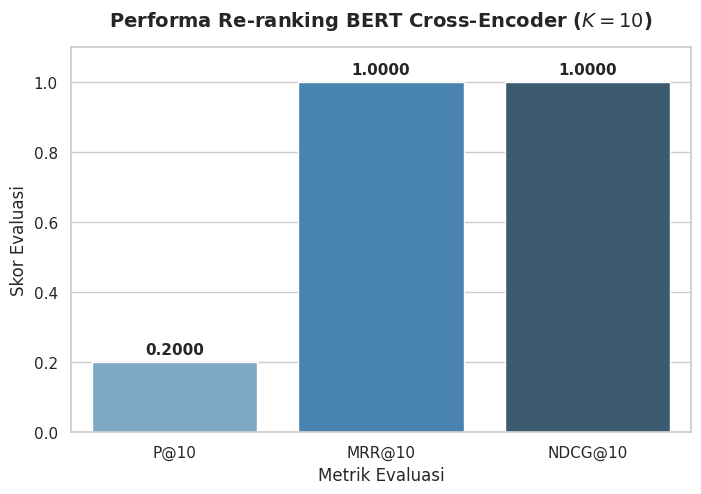

In [38]:
## Part Tambahan: Visualisasi Hasil Metrik Evaluasi
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi menggunakan seaborn
sns.set_theme(style="whitegrid")

# 1. Membuat Grafik Batang Hasil Metrik IR
names = list(ir_results.keys())
values = list(ir_results.values())

plt.figure(figsize=(8, 5))
barplot = sns.barplot(x=names, y=values, palette="Blues_d")

# Menambahkan angka di atas setiap bar grafik
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.4f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=11, fontweight='bold')

plt.title("Performa Re-ranking BERT Cross-Encoder ($K=10$)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Skor Evaluasi", fontsize=12)
plt.ylim(0, 1.1) # Batas atas grafik dilebihkan sedikit agar teks angka tidak terpotong
plt.xlabel("Metrik Evaluasi", fontsize=12)

# Simpan grafik untuk di-SS ke laporan
plt.savefig("ir_metrics_performance.png", dpi=300, bbox_inches='tight')
plt.show()